<a href="https://colab.research.google.com/github/Bhanupratap03/vehicle_plate_detection/blob/main/vehicle_plate_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
%pip install ultralytics pyyaml

In [ ]:
import yaml

In [12]:
!unzip /content/vehicle_plate_detection.zip -d /content/dataset

unzip:  cannot find or open /content/vehicle_plate_detection.zip, /content/vehicle_plate_detection.zip.zip or /content/vehicle_plate_detection.zip.ZIP.


In [13]:
import zipfile
import os

zip_path = '/content/vehicle-plate-detection.zip'

# Quick check to make sure the file actually exists and isn't 0 bytes
if os.path.exists(zip_path) and os.path.getsize(zip_path) > 1000:
    print("File looks good! Unzipping now...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/dataset')
    print("Success! Dataset is ready.")
else:
    print("Error: The file is missing or corrupted. The upload might have failed.")

File looks good! Unzipping now...
Success! Dataset is ready.


In [14]:
import zipfile
zip_ref = zipfile.ZipFile('/content/vehicle-plate-detection.zip')
zip_ref.extractall('/content/content/vechical-plate-detection')
zip_ref.close()

In [18]:
with open('/content/content/vechical-plate-detection/vechical-plate-detection/data.yml','r') as f:
  data = yaml.safe_load(f)

print(data)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 2, 'names': ['vehicle', 'license-plate']}


In [20]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [23]:
!yolo task=detect \
    mode=train \
    model=yolov8s.pt \
    data=/content/content/vechical-plate-detection/vechical-plate-detection/data.yml \
    epochs=2 \
    imgsz=640 \
    batch=16

Ultralytics 8.4.24 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/content/vechical-plate-detection/vechical-plate-detection/data.yml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto

In [21]:
%pip install -q pytesseract
!apt-get install -y tesseract-ocr
%pip install -q cvzone

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.
  Preparing metadata (setup.py) ... done



0: 448x640 5 vehicles, 1 license-plate, 506.2ms
Speed: 4.1ms preprocess, 506.2ms inference, 9.2ms postprocess per image at shape (1, 3, 448, 640)
Detected Plate Text: DL7001939}


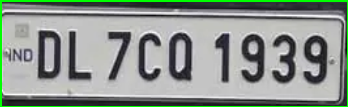

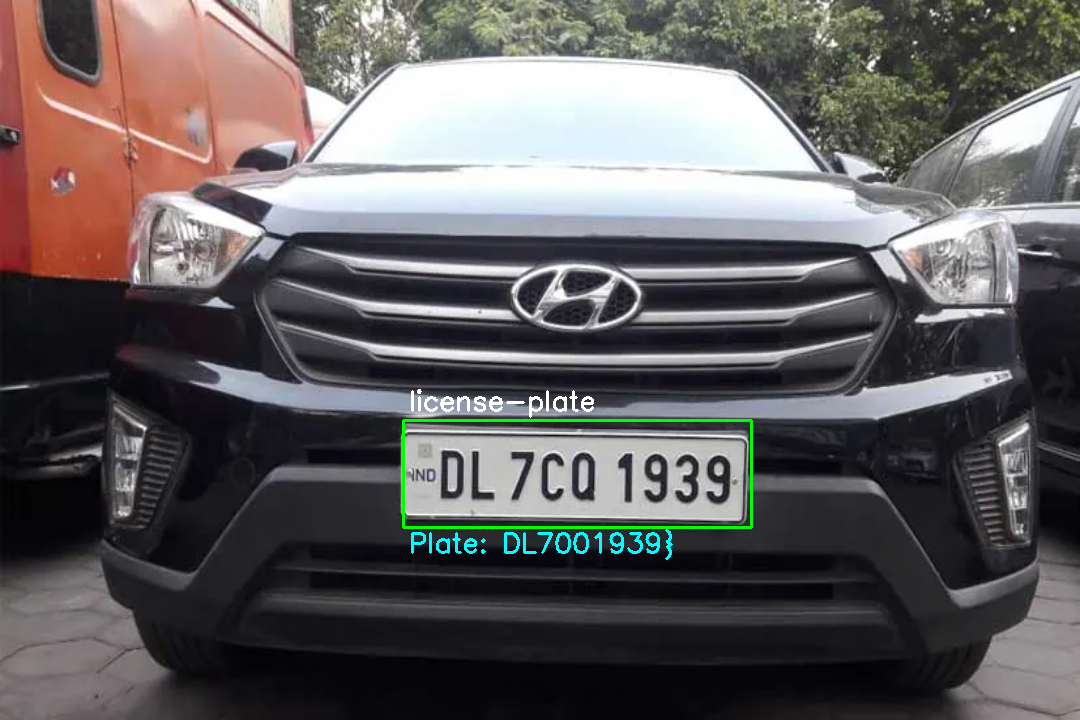

In [27]:
import cv2
import pytesseract
import yaml
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# Load class names from data.yml
with open('/content/content/vechical-plate-detection/vechical-plate-detection/data.yml', 'r') as f:
    data = yaml.safe_load(f)
classnames = data['names']

# Load image
image_path = '/content/car.webp'
frame = cv2.imread(image_path)
frame = cv2.resize(frame, (1080, 720))

# Load YOLOv8 model
model = YOLO('/content/runs/detect/train2/weights/best.pt')  # Update path as needed

# Run YOLO detection
results = model(frame)

# Process detections
for r in results:
    for box in r.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        class_id = int(box.cls[0])

        # Safety check to avoid index errors
        if class_id >= len(classnames):
            continue
        class_name = classnames[class_id]

        # Focus only on license plates
        if conf > 0.5 and class_name == 'license-plate':
            # Crop plate region
            plate_crop = frame[y1:y2, x1:x2]

            # Preprocess for OCR
            gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
            _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

            # OCR with pytesseract
            plate_text = pytesseract.image_to_string(thresh, config='--psm 7')
            plate_text_cleaned = plate_text.strip().replace("\n", "").replace(" ", "")
            print("Detected Plate Text:", plate_text_cleaned)

            # Draw bounding box and label
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f'{class_name}', (x1 + 5, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
            cv2.putText(frame, f'Plate: {plate_text_cleaned}', (x1 + 5, y2 + 25),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)

            # Show cropped plate
            cv2_imshow(plate_crop)

# Show full frame with annotations
cv2_imshow(frame)
